In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [2]:
n = 3
main = QuantumRegister(n, "j")
ancillae = QuantumRegister(2, "anc")

simulator = AerSimulator(method="unitary")

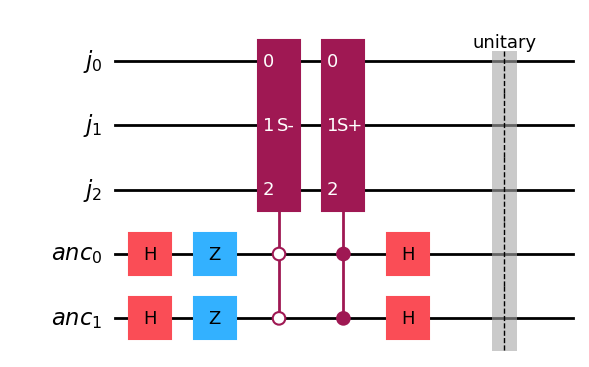

In [3]:
csdown = ShiftDown(n).control(2, ctrl_state=0)
csup = ShiftUp(n).control(2, ctrl_state=3)
qc = QuantumCircuit(main, ancillae)

# Block encoding
qc.h(ancillae)
qc.z(ancillae)
qc.append(csdown, ancillae[:] + main[:])
qc.append(csup, ancillae[:] + main[:])
qc.h(ancillae)
qc.save_unitary()

qc.draw(output="mpl")

In [12]:
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data

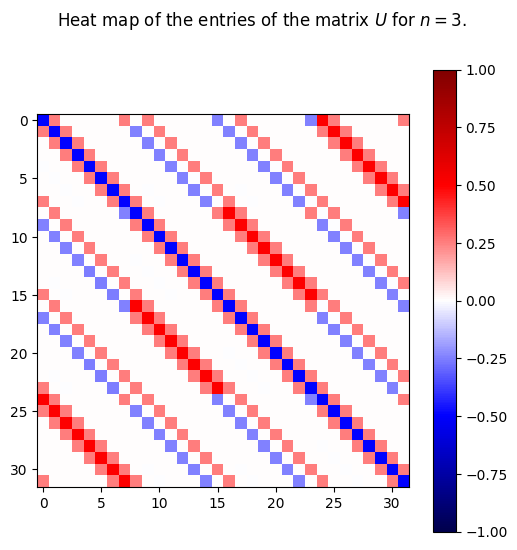

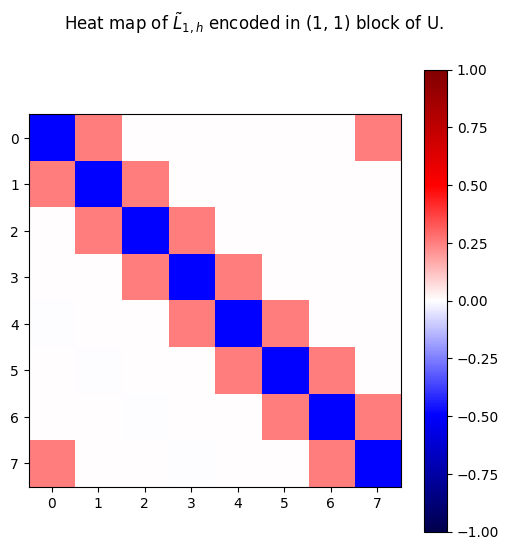

In [18]:
plt.figure(figsize=(6, 6))
plt.suptitle("Heat map of the entries of the matrix $U$ for $n = 3$.")
plt.imshow(unitary.real, cmap="seismic", vmin=-1, vmax=1)
plt.colorbar()
plt.show()

plt.figure(figsize=(6, 6))
plt.suptitle("Heat map of $\\tilde{L}_{{1, h}}$ encoded in (1, 1) block of U.")
plt.imshow(unitary[:8, :8].real, cmap="seismic", vmin=-1, vmax=1)
plt.colorbar()
plt.show()